<a href="https://colab.research.google.com/github/andressonsino/red-neuronal-multicapa/blob/main/rrnn_multicapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Clasificación de Ropa con Fashion MNIST
**Consigna:** El objetivo de este ejercicio es diseñar, entrenar y evaluar una red neuronal profunda (MLP) capaz de clasificar imágenes de 28x28 píxeles en 10 categorías de vestimenta. Deberás completar las secciones de código indicadas para que el modelo logre una precisión aceptable en el set de prueba.

## 1. Carga de Datos y Preprocesamiento
El primer paso es normalizar las imágenes. Como las redes neuronales son calculadoras de promedios ponderados, es vital que las entradas estén en la misma escala (generalmente entre 0 y 1) para evitar que magnitudes grandes dominen el aprendizaje.

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Cargamos el dataset de ropa
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Etiquetas de las 10 categorías
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# AYUDA: Dividir los arreglos por 255.0 para normalizar los píxeles al rango [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

## 2. Definición de la Arquitectura (MLP)
Configurar las capas de la red. Recirdar que la Capa de Entrada debe **"aplanar"** la matriz de 28x28. En las Capas Ocultas, utilizamos la función **ReLU** por su eficiencia para transmitir señales positivas . Finalmente, la Capa de Salida debe tener 10 neuronas (una por cada prenda) y usar **Softmax** para entregar una distribución de probabilidad que sume 1 .

Se eligió una arquitectura simplificada de una sola capa oculta con 64 neuronas.
Fashion MNIST no requiere mayor profundidad dado que las imágenes son pequeñas
(28x28 píxeles) en escala de grises. Esta decisión reduce el costo computacional
manteniendo un accuracy de ~88% en el set de prueba.


In [7]:
model = models.Sequential([
    # Capa de Entrada: Aplana la imagen de 28x28 a un vector de 784
    layers.Flatten(input_shape=(28, 28)),

    # AYUDA: Agrega otra capa densa con 64 neuronas y activación 'relu'
    layers.Dense(64, activation = "relu", name = "capa_oculta_1"),

    # Capa de Salida: 10 neuronas para las 10 clases de ropa
    # AYUDA: ¿Qué función de activación se usa para clasificación multiclase?
    layers.Dense(10, activation='softmax', name = "salida_probabilistica")
])

## 3. Compilación y Entrenamiento
Para que la red aprenda, aplicamos el algoritmo de Backpropagation. Configuraremos el optimizador para ajustar los pesos y una función de pérdida que mida la discrepancia entre la predicción y la realidad

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# AYUDA: Implementar Early Stopping para monitorear 'val_loss' y evitar el sobreajuste
# Esto detendrá el entrenamiento si el error de validación deja de mejorar.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor= "val_loss",
    patience=5,
    restore_best_weights=True
)

# Entrenamiento
history = model.fit(
    train_images, train_labels,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8131 - loss: 0.5414 - val_accuracy: 0.8461 - val_loss: 0.4302
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8540 - loss: 0.4105 - val_accuracy: 0.8610 - val_loss: 0.3841
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8696 - loss: 0.3676 - val_accuracy: 0.8625 - val_loss: 0.3780
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8753 - loss: 0.3408 - val_accuracy: 0.8695 - val_loss: 0.3644
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8824 - loss: 0.3238 - val_accuracy: 0.8760 - val_loss: 0.3465
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8861 - loss: 0.3088 - val_accuracy: 0.8693 - val_loss: 0.3610
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8905 - loss: 0.2951 - val_accuracy: 0.8755 - val_loss: 0.3518
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8955 - loss: 0.2833 - 

## 4. Evaluación y Predicción
Una vez entrenada, es fundamental evaluar el modelo con datos que nunca ha visto (set de prueba) para verificar su capacidad de generalización y asegurar que no solo memorizó los ejemplos de entrenamiento

313/313 - 1s - 2ms/step - accuracy: 0.8792 - loss: 0.3479

Precisión en el set de prueba: 87.92%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


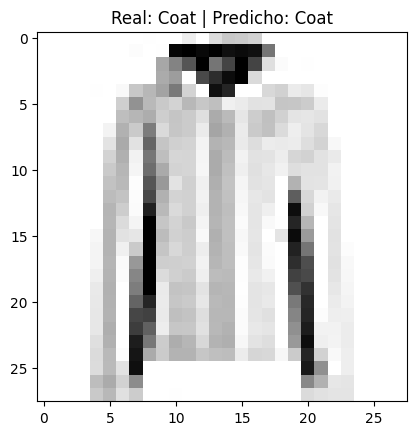

In [9]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nPrecisión en el set de prueba: {test_acc:.2%}')

# AYUDA: Realiza una predicción sobre el set de prueba
predictions = model.predict(test_images)

# Visualización de una predicción individual
n = 6 # Puedes cambiar este índice
plt.imshow(test_images[n], cmap=plt.cm.binary)
plt.title(f"Real: {class_names[test_labels[n]]} | Predicho: {class_names[np.argmax(predictions[n])]}")
plt.show()

# 5. Accuracy y pérdida



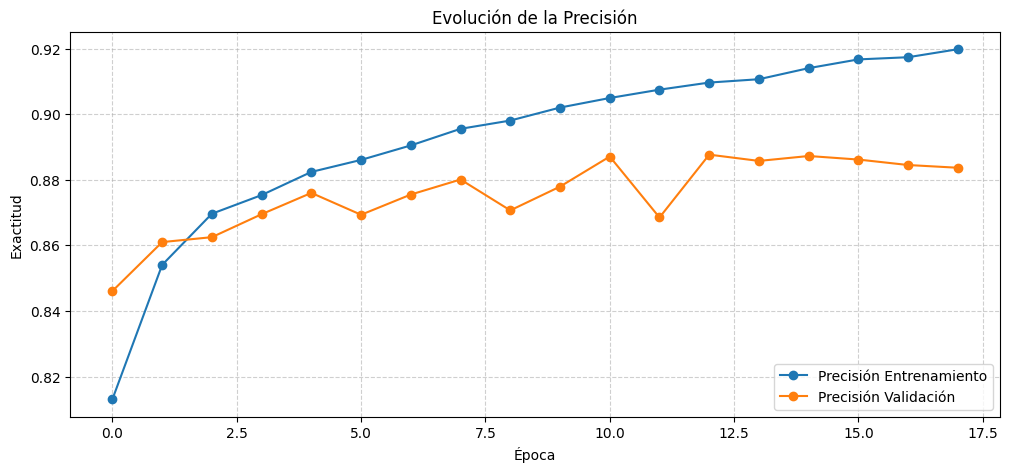

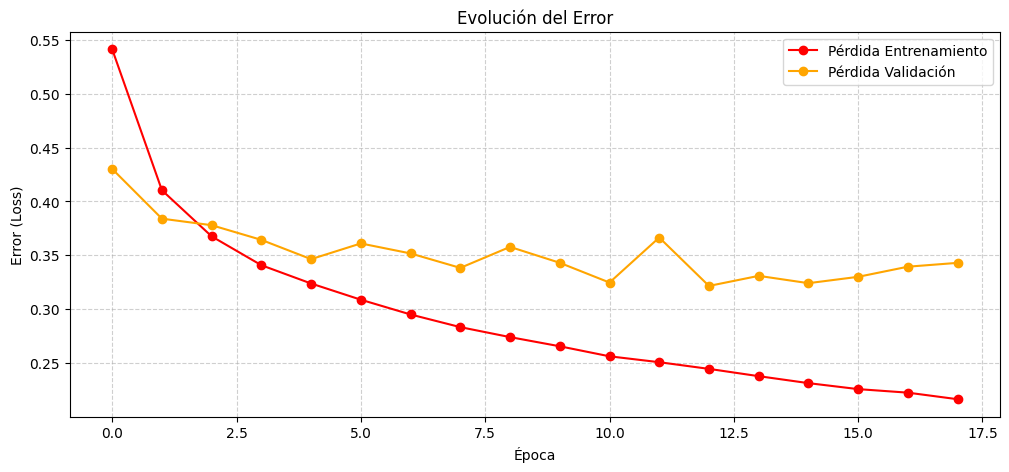

In [10]:
# --- GRÁFICO 1: PRECISIÓN ---
plt.figure(figsize=(12, 5)) # 1. Primero preparamos la hoja
plt.grid(True, linestyle='--', alpha=0.6) # 2. Agregamos la grilla

# 3. Dibujamos las líneas (agregué el marker='o' para ver los puntos de cada época)
plt.plot(history.history['accuracy'], marker='o', label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], marker='o', label='Precisión Validación')

# 4. Decoramos
plt.title('Evolución de la Precisión')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.show() # 5. Mostramos este gráfico antes de empezar el otro

# --- GRÁFICO 2: PÉRDIDA ---
plt.figure(figsize=(12, 5)) # Nueva hoja para el segundo gráfico
plt.grid(True, linestyle='--', alpha=0.6)

plt.plot(history.history['loss'], marker='o', color='red', label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], marker='o', color='orange', label='Pérdida Validación')

plt.title('Evolución del Error')
plt.xlabel('Época')
plt.ylabel('Error (Loss)')
plt.legend(loc='upper right')
plt.show()

## Guía:
- **Normalización:** Si olvidas este paso, notarás que el error (loss) baja muy lentamente o el modelo no converge.
- **Activaciones:** ¿Qué sucede si usas una función lineal en lugar de ReLU en las capas ocultas? La red perdería su capacidad de detectar patrones complejos.
- **Softmax:** Observa cómo las 10 salidas de la última capa compiten entre sí; la prenda con el valor más alto es la elegida por el sistema .